In [42]:
import pandas as pd
import numpy as np

from pathlib import Path

DATA_DIR = Path("../data/processed")

train_features = pd.read_csv(DATA_DIR / "train_features.csv")
test_features = pd.read_csv(DATA_DIR / "test_features.csv")

train_signals = pd.read_csv(
    "../data/raw/train_signals.csv"
)

test_signals = pd.read_csv(
    "../data/raw/test_signals.csv"
)

train_transactions = pd.read_parquet(
    "../data/raw/train_transactions.parquet"
)

test_transactions = pd.read_parquet(
    "../data/raw/test_transactions.parquet"
)

print(train_features.shape)     
print(test_features.shape)

(14000, 24)
(6000, 23)


In [2]:
X = train_features.drop(columns=["signal_id", "eskalatsiya"])
y = train_features["eskalatsiya"]

X_test = test_features.drop(columns=["signal_id"])

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (14000, 22)
y: (14000,)
X_test: (6000, 22)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (11200, 22)
Validation: (2800, 22)


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [5]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [6]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['transaction_count','miqdor_mean','miqdor_median',...,'miqdor_q75', 'miqdor_q90','miqdor_iqr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [7]:
val_pred = baseline_model.predict_proba(X_val)[:, 1]

print(val_pred[:10])

[0.15739326 0.10304983 0.17831164 0.22593607 0.16109337 0.18304388
 0.19503312 0.13176752 0.19380781 0.18652884]


In [8]:
from sklearn.metrics import roc_auc_score

baseline_auc = roc_auc_score(y_val, val_pred)

print(f"Baseline ROC-AUC: {baseline_auc:.4f}")

Baseline ROC-AUC: 0.5684


In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier


In [10]:
model_hgb = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

In [11]:
model_hgb.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [12]:
val_pred_hgb = model_hgb.predict_proba(X_val)[:, 1]

In [13]:
hgb_auc = roc_auc_score(y_val, val_pred_hgb)

print(f"HistGradientBoosting ROC-AUC: {hgb_auc:.4f}")

HistGradientBoosting ROC-AUC: 0.6030


In [14]:
from sklearn.inspection import permutation_importance

In [15]:
importance = permutation_importance(
    model_hgb,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

In [16]:
feature_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std
})

feature_importance = feature_importance.sort_values(
    "importance_mean",
    ascending=False
)

feature_importance

,feature,importance_mean,importance_std
4,miqdor_min,0.067607,0.008568
5,miqdor_max,0.023809,0.007814
8,kirim_ratio,0.008013,0.004485
19,miqdor_q75,0.006902,0.001250
11,naqd_count,0.004063,0.003878
20,miqdor_q90,0.002840,0.003133
6,chiqim_count,0.002647,0.004646
13,tx_1d,0.002326,0.001335
1,miqdor_mean,0.002169,0.000864
21,miqdor_iqr,0.001908,0.001671


In [17]:
train_features.groupby("eskalatsiya")[
    ["miqdor_min", "miqdor_max", "miqdor_mean", "miqdor_median"]
].agg(["mean", "median", "std", "min", "max"])

miqdor_min                                         miqdor_max  \
                  mean    median       std       min       max       mean   
eskalatsiya                                                                 
0            -2.327691 -2.419015  0.594957 -2.912314  5.096718   3.052133   
1            -2.353069 -2.462913  0.563591 -2.912309  3.405806   2.881728   

                                                    miqdor_mean            \
               median       std       min       max        mean    median   
eskalatsiya                                                                 
0            2.992033  1.076565 -2.188280  6.691657   -0.045165 -0.069304   
1            2.817033  1.033368 -1.527981  6.463725   -0.116044 -0.143600   

                                          miqdor_median                      \
                  std       min       max          mean    median       std   
eskalatsiya                                                                   
0            0.510409 -2.188280  5.096718     -0.101026 -0.137990  0.507489   
1            0.503257 -1.738993  3.405806     -0.165319 -0.193729  0.502304   

                                 
                  min       max  
eskalatsiya                      
0           -2.188280  5.096718  
1           -1.718239  3.405806

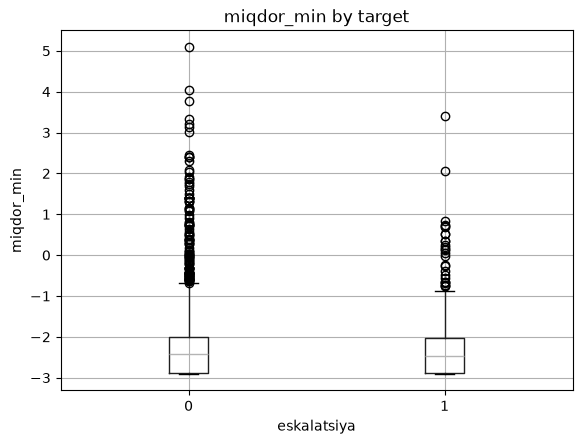

In [18]:
import matplotlib.pyplot as plt

train_features.boxplot(
    column="miqdor_min",
    by="eskalatsiya"
)

plt.title("miqdor_min by target")
plt.suptitle("")
plt.xlabel("eskalatsiya")
plt.ylabel("miqdor_min")
plt.show()

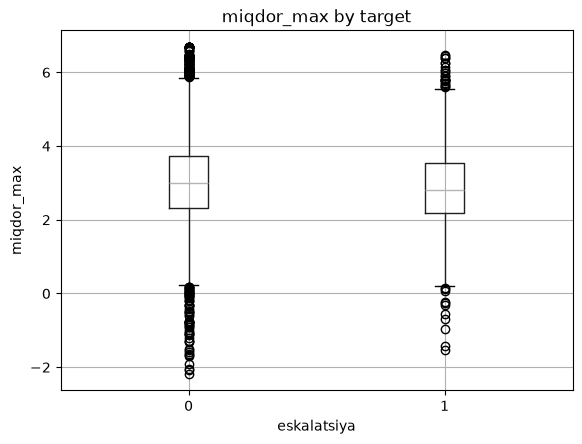

In [19]:
train_features.boxplot(
    column="miqdor_max",
    by="eskalatsiya"
)

plt.title("miqdor_max by target")
plt.suptitle("")
plt.xlabel("eskalatsiya")
plt.ylabel("miqdor_max")
plt.show()

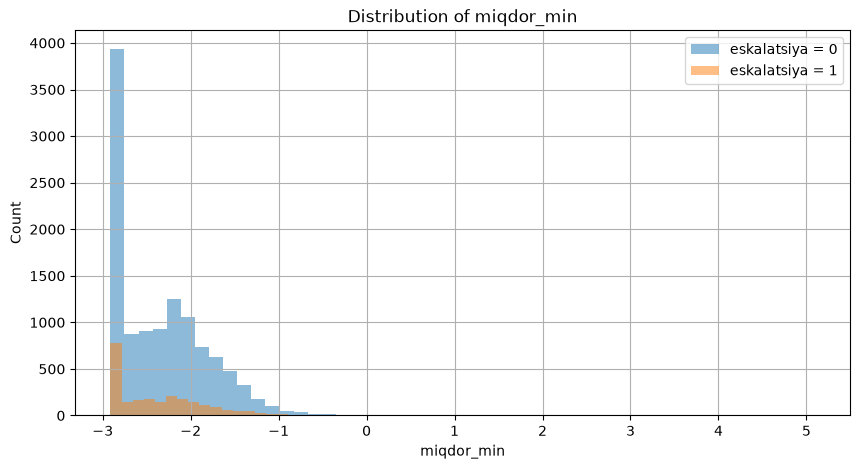

In [20]:
plt.figure(figsize=(10, 5))

train_features.loc[
    train_features["eskalatsiya"] == 0,
    "miqdor_min"
].hist(
    bins=50,
    alpha=0.5,
    label="eskalatsiya = 0"
)

train_features.loc[
    train_features["eskalatsiya"] == 1,
    "miqdor_min"
].hist(
    bins=50,
    alpha=0.5,
    label="eskalatsiya = 1"
)

plt.xlabel("miqdor_min")
plt.ylabel("Count")
plt.title("Distribution of miqdor_min")
plt.legend()
plt.show()

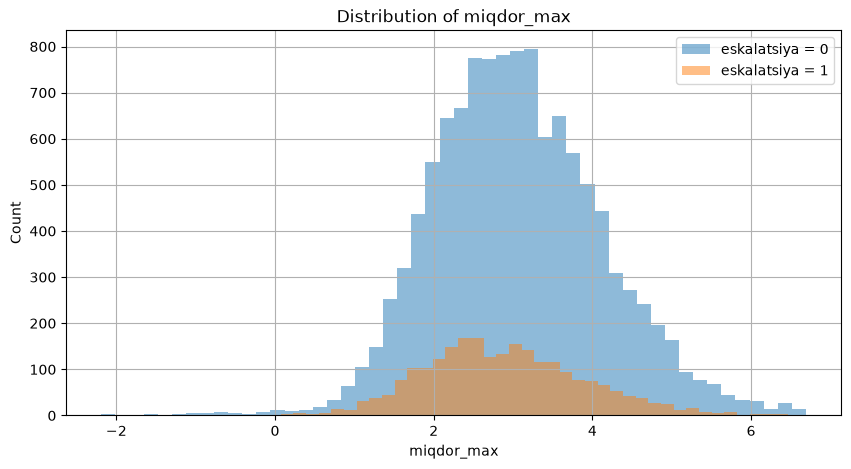

In [21]:
plt.figure(figsize=(10, 5))

train_features.loc[
    train_features["eskalatsiya"] == 0,
    "miqdor_max"
].hist(
    bins=50,
    alpha=0.5,
    label="eskalatsiya = 0"
)

train_features.loc[
    train_features["eskalatsiya"] == 1,
    "miqdor_max"
].hist(
    bins=50,
    alpha=0.5,
    label="eskalatsiya = 1"
)

plt.xlabel("miqdor_max")
plt.ylabel("Count")
plt.title("Distribution of miqdor_max")
plt.legend()
plt.show()

In [22]:
X = train_features.drop(
    columns=["signal_id", "eskalatsiya"]
)

y = train_features["eskalatsiya"]

X_test = test_features.drop(
    columns=["signal_id"]
)

print(X.shape)
print(X_test.shape)

(14000, 22)
(6000, 22)


In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [24]:
model_hgb_features = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

model_hgb_features.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [25]:
val_pred_features = model_hgb_features.predict_proba(
    X_val
)[:, 1]

In [26]:
hgb_features_auc = roc_auc_score(
    y_val,
    val_pred_features
)

print(
    f"HGB with new features ROC-AUC: "
    f"{hgb_features_auc:.4f}"
)

HGB with new features ROC-AUC: 0.6030


In [27]:
DATA_DIR = Path("../data/raw")
train_signals = pd.read_csv(
    DATA_DIR / "train_signals.csv"
)

train_signals["signal_sanasi"] = pd.to_datetime(
    train_signals["signal_sanasi"]
)

In [28]:
print(
    train_signals["signal_sanasi"]
    .sort_values()
    .iloc[[0, -1]]
)

13220   2025-01-01
9173    2026-12-31
Name: signal_sanasi, dtype: datetime64[us]


In [29]:
train_features = train_features.merge(
    train_signals[["signal_id", "signal_sanasi"]],
    on="signal_id",
    how="left"
)

In [30]:
print(train_features[["signal_id", "signal_sanasi"]].head())

   signal_id signal_sanasi
0  SG_000002    2026-08-02
1  SG_000003    2025-12-15
2  SG_000004    2026-02-13
3  SG_000005    2026-02-05
4  SG_000006    2025-04-18


In [31]:
split_date = train_features["signal_sanasi"].quantile(0.8)

print("Split date:", split_date)

Split date: 2026-06-06 00:00:00


In [32]:
train_mask = train_features["signal_sanasi"] < split_date
val_mask = train_features["signal_sanasi"] >= split_date

print("Train:", train_mask.sum())
print("Validation:", val_mask.sum())

Train: 11183
Validation: 2817


In [33]:
feature_columns = [
    col for col in train_features.columns
    if col not in ["signal_id", "eskalatsiya", "signal_sanasi"]
]

X_time = train_features[feature_columns]
y_time = train_features["eskalatsiya"]

X_train_time = X_time[train_mask]
X_val_time = X_time[val_mask]

y_train_time = y_time[train_mask]
y_val_time = y_time[val_mask]

print(X_train_time.shape)
print(X_val_time.shape)

(11183, 22)
(2817, 22)


In [34]:
model_hgb_time = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

model_hgb_time.fit(
    X_train_time,
    y_train_time
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [35]:
val_pred_time = model_hgb_time.predict_proba(
    X_val_time
)[:, 1]

In [36]:
time_auc = roc_auc_score(
    y_val_time,
    val_pred_time
)

print(f"Time-based ROC-AUC: {time_auc:.4f}")

Time-based ROC-AUC: 0.6161


In [37]:
model_hgb_v2 = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

model_hgb_v2.fit(
    X_train_time,
    y_train_time
)

val_pred_v2 = model_hgb_v2.predict_proba(
    X_val_time
)[:, 1]

auc_v2 = roc_auc_score(
    y_val_time,
    val_pred_v2
)

print(f"HGB v2 Time-based ROC-AUC: {auc_v2:.4f}")

HGB v2 Time-based ROC-AUC: 0.6080


In [ ]:
model_hgb_v3 = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.03,
    max_leaf_nodes=15,
    random_state=42
)

model_hgb_v3.fit(X_train_time, y_train_time)

val_pred_v3 = model_hgb_v3.predict_proba(X_val_time)[:, 1]

auc_v3 = roc_auc_score(y_val_time, val_pred_v3)

print(f"HGB v3 Time-based ROC-AUC: {auc_v3:.4f}")

HGB v3 Time-based ROC-AUC: 0.6212


In [43]:
train_signals["signal_sanasi"] = pd.to_datetime(
    train_signals["signal_sanasi"]
)

test_signals["signal_sanasi"] = pd.to_datetime(
    test_signals["signal_sanasi"]
)

train_transactions["tranzaksiya_vaqti"] = pd.to_datetime(
    train_transactions["tranzaksiya_vaqti"]
)

test_transactions["tranzaksiya_vaqti"] = pd.to_datetime(
    test_transactions["tranzaksiya_vaqti"]
)

In [45]:
train_tx = train_transactions.merge(
    train_signals[["signal_id", "signal_sanasi"]],
    on="signal_id",
    how="left"
)

train_tx = train_tx[
    train_tx["tranzaksiya_vaqti"] <= train_tx["signal_sanasi"]
].copy()

train_tx["days_before_signal"] = (
    train_tx["signal_sanasi"]
    - train_tx["tranzaksiya_vaqti"]
).dt.total_seconds() / (24 * 60 * 60)

In [49]:
test_tx = test_transactions.merge(
    test_signals[["signal_id", "signal_sanasi"]],
    on="signal_id",
    how="left"
)

test_tx = test_tx[
    test_tx["tranzaksiya_vaqti"] <= test_tx["signal_sanasi"]
].copy()

test_tx["days_before_signal"] = (
    test_tx["signal_sanasi"]
    - test_tx["tranzaksiya_vaqti"]
).dt.total_seconds() / (24 * 60 * 60)

In [50]:
feature_cols = [
    col for col in train_features.columns
    if col not in ["signal_id", "signal_sanasi", "eskalatsiya"]
]


In [51]:
X_train = train_features.loc[train_mask, feature_cols]
y_train = train_features.loc[train_mask, "eskalatsiya"]

X_val = train_features.loc[val_mask, feature_cols]
y_val = train_features.loc[val_mask, "eskalatsiya"]

In [52]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

val_pred_rf = model_rf.predict_proba(X_val)[:, 1]

auc_rf = roc_auc_score(y_val, val_pred_rf)

print(f"Random Forest ROC-AUC: {auc_rf:.4f}")

Random Forest ROC-AUC: 0.6011


In [ ]:
import xgboost

print(xgboost.__version__)